# Praktikum Pengolahan Citra
## Sub-CPMK 2: Histogram dan Karakteristik Citra

**Tujuan sesi ini:** setelah praktikum ini, kamu bisa membaca histogram untuk menyimpulkan kecerahan dan kontras sebuah citra, menghitung statistik dasarnya (mean, standar deviasi), dan menentukan metode pengolahan yang sesuai berdasarkan bentuk histogram.

**Cara pakai notebook ini:** jalankan tiap sel dari atas ke bawah (`Shift+Enter`). Sel bertanda **Latihan** berisi kode yang belum lengkap, bagian `# TODO` harus kamu isi sendiri.

Notebook ini menyambung dari praktikum Sub-CPMK 1 (piksel, channel, sampling, kuantisasi). Kalau istilah "channel" atau "grayscale" belum familiar, cek lagi notebook sebelumnya dulu.

---

## Nama: Davidson Rafael Krisman Nugroho
## NIM: 412024030

## Bagian 0 - Persiapan

Jalankan sel-sel di bawah ini sekali di awal sesi.

In [38]:
# Kalau ada modul yang belum terpasang (biasanya tidak perlu di Google Colab), uncomment baris berikut:
# !pip install -q opencv-python numpy matplotlib scikit-image

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data as skdata

%matplotlib inline

print("OpenCV :", cv2.__version__)
print("NumPy  :", np.__version__)

OpenCV : 4.14.0
NumPy  : 2.1.3


Citra contoh sama dengan yang dipakai di notebook Sub-CPMK 1, supaya hasil di kedua notebook bisa dibandingkan langsung.

In [39]:
rgb_sample = skdata.astronaut()
cv2.imwrite("wony.jpg", cv2.cvtColor(rgb_sample, cv2.COLOR_RGB2BGR))

img = cv2.imread("wony.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
print("citra siap:", img_rgb.shape)

citra siap: (512, 512, 3)


In [40]:
# OPSIONAL: jalankan sel ini kalau mau pakai foto sendiri (menimpa citra.jpg)
from google.colab import files
import shutil

uploaded = files.upload()
nama_file = list(uploaded.keys())[0]
shutil.copy(nama_file, "wony.jpg")

img = cv2.imread("wony.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
print("Terpasang sebagai citra.jpg,", img_rgb.shape)

Saving 4d6543f8d9609624d92cc8d4eb8b0dae.jpg to 4d6543f8d9609624d92cc8d4eb8b0dae (1).jpg
Terpasang sebagai citra.jpg, (980, 736, 3)


## Bagian 1 · Apa Itu Histogram Citra?

Histogram adalah grafik yang menghitung: dari intensitas 0 sampai 255, berapa banyak piksel yang punya tiap nilai itu. Sumbu mendatar = level intensitas, sumbu tegak = jumlah piksel.

Histogram TIDAK menyimpan posisi piksel sama sekali, cuma menghitung berapa kali tiap nilai muncul. Itu sebabnya dua citra yang tampilannya beda total bisa saja punya histogram yang mirip.

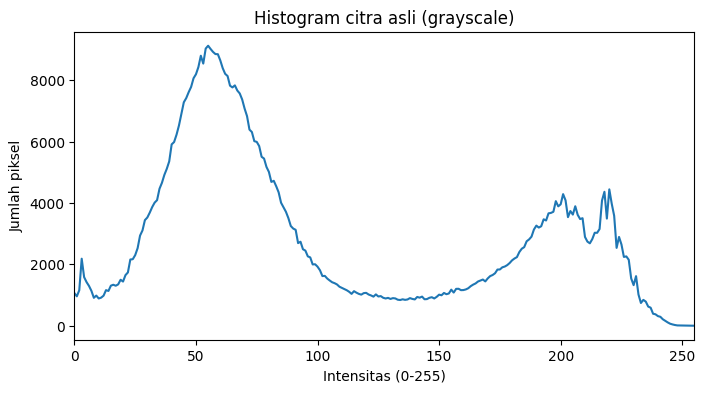

Total dihitung histogram: 721280
Total piksel citra      : 721280


In [41]:
hist = cv2.calcHist([gray], [0], None, [256], [0, 256])

plt.figure(figsize=(8, 4))
plt.plot(hist)
plt.xlim(0, 255)
plt.xlabel("Intensitas (0-255)")
plt.ylabel("Jumlah piksel")
plt.title("Histogram citra asli (grayscale)")
plt.show()

print("Total dihitung histogram:", int(hist.sum()))
print("Total piksel citra      :", gray.shape[0] * gray.shape[1])

Kedua angka di atas seharusnya sama persis. Itu bukti bahwa histogram menghitung SETIAP piksel tepat satu kali, tidak ada yang terlewat atau dihitung dua kali.

### Bonus (opsional): Histogram Kumulatif

Kalau histogram biasa menghitung "berapa piksel di nilai X", histogram kumulatif menghitung "berapa piksel di nilai ≤ X". Ini akan dipakai lagi minggu depan untuk histogram equalization.

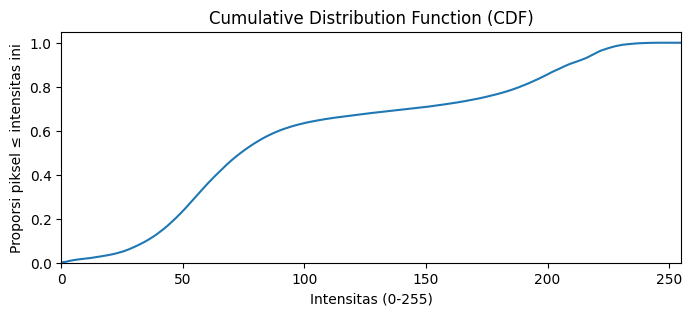

In [42]:
cdf = hist.cumsum()

plt.figure(figsize=(8, 3))
plt.plot(cdf / cdf.max())
plt.xlim(0, 255)
plt.ylim(0, 1.05)
plt.xlabel("Intensitas (0-255)")
plt.ylabel("Proporsi piksel ≤ intensitas ini")
plt.title("Cumulative Distribution Function (CDF)")
plt.show()

## Bagian 2 · Histogram vs Kecerahan (Gelap/Terang)

Citra gelap punya histogram yang condong ke kiri (banyak piksel di nilai rendah). Citra terang condong ke kanan.

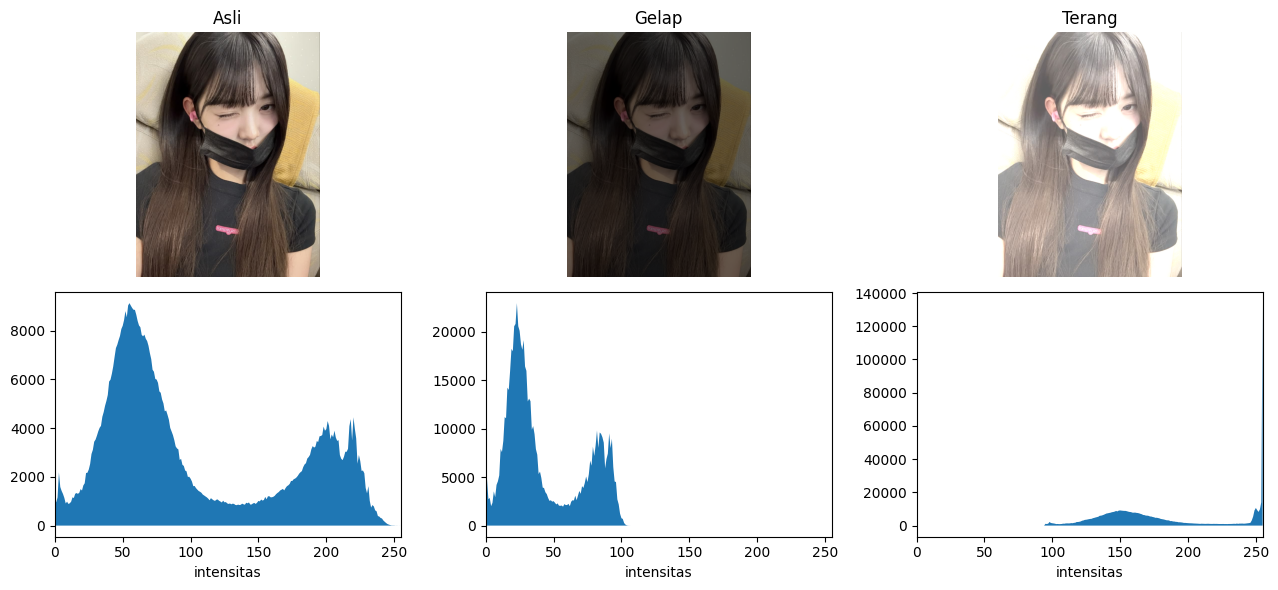

In [43]:
def tampilkan_dengan_histogram(citra_list, judul_list):
    # Tampilkan beberapa citra RGB berdampingan, masing-masing dengan histogram grayscale-nya
    n = len(citra_list)
    fig, ax = plt.subplots(2, n, figsize=(4.3 * n, 6))
    if n == 1:
        ax = ax.reshape(2, 1)
    for i, (c, j) in enumerate(zip(citra_list, judul_list)):
        g = cv2.cvtColor(c, cv2.COLOR_RGB2GRAY)
        ax[0, i].imshow(c)
        ax[0, i].set_title(j)
        ax[0, i].axis("off")
        h = cv2.calcHist([g], [0], None, [256], [0, 256])
        ax[1, i].fill_between(np.arange(256), h.flatten())
        ax[1, i].set_xlim(0, 255)
        ax[1, i].set_xlabel("intensitas")
    plt.tight_layout()
    plt.show()

gelap = np.clip(img_rgb.astype(np.int16) * 0.42, 0, 255).astype(np.uint8)
terang = np.clip(img_rgb.astype(np.int16) * 1.0 + 95, 0, 255).astype(np.uint8)

tampilkan_dengan_histogram([img_rgb, gelap, terang], ["Asli", "Gelap", "Terang"])

## Bagian 3 · Histogram vs Kontras (Rendah/Tinggi)

Kontras rendah = histogram sempit, terkumpul di satu area. Kontras tinggi = histogram melebar dari 0 sampai 255.

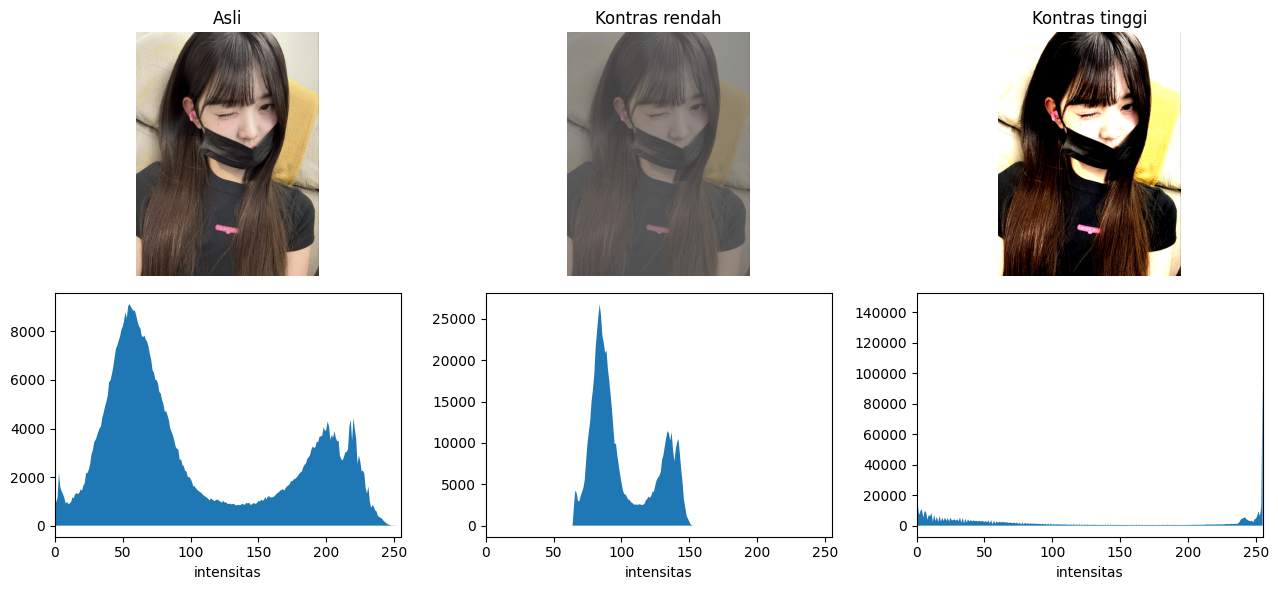

In [44]:
mean_val = img_rgb.astype(np.float32).mean()
rendah = np.clip(mean_val + (img_rgb.astype(np.float32) - mean_val) * 0.35, 0, 255).astype(np.uint8)
tinggi = np.clip(mean_val + (img_rgb.astype(np.float32) - mean_val) * 2.1, 0, 255).astype(np.uint8)

tampilkan_dengan_histogram([img_rgb, rendah, tinggi], ["Asli", "Kontras rendah", "Kontras tinggi"])

In [45]:
hist, bins = np.histogram(tinggi.flatten(), bins=256, range=(0, 256))

total_pixels = tinggi.size
print("Total piksel gambar:", total_pixels)
print("Sum semua bin histogram:", hist.sum())

print(f"hist[0]   = {hist[0]}")
print(f"hist[1]   = {hist[1]}")
print(f"hist[2]   = {hist[2]}")
print(f"...")
print(f"hist[253] = {hist[253]}")
print(f"hist[254] = {hist[254]}")
print(f"hist[255] = {hist[255]}")

max_bin = np.argmax(hist)
print(f"\nBin tertinggi ada di intensitas: {max_bin}, dengan jumlah piksel: {hist[max_bin]}")

persen_clip = (hist[0] + hist[255]) / total_pixels * 100
print(f"\nPersentase piksel yang clip ke 0 atau 255: {persen_clip:.2f}%")

Total piksel gambar: 2163840
Sum semua bin histogram: 2163840
hist[0]   = 618969
hist[1]   = 0
hist[2]   = 27014
...
hist[253] = 0
hist[254] = 5973
hist[255] = 469113

Bin tertinggi ada di intensitas: 0, dengan jumlah piksel: 618969

Persentase piksel yang clip ke 0 atau 255: 50.28%


Tambahan informasi untuk kontras tinggi bisa dilihat pada hasil histogram di atas untuk `histogram[0]` bar pertama memiliki data/pixel sebesar `618969` dan `hist[255] 469113`. Ini membuat spike di range lain menjadi terlihat lebih kecil jika divisualisasikan dengan histogram

### Latihan 1

Buat SATU versi citra dengan tingkat kecerahan pilihanmu sendiri (bukan angka 0.42 atau +95 seperti di atas). Sebelum menjalankan sel kode, isi dulu tebakanmu di komentar paling atas: histogramnya akan condong ke kiri atau ke kanan? Baru jalankan dan cek tebakanmu.

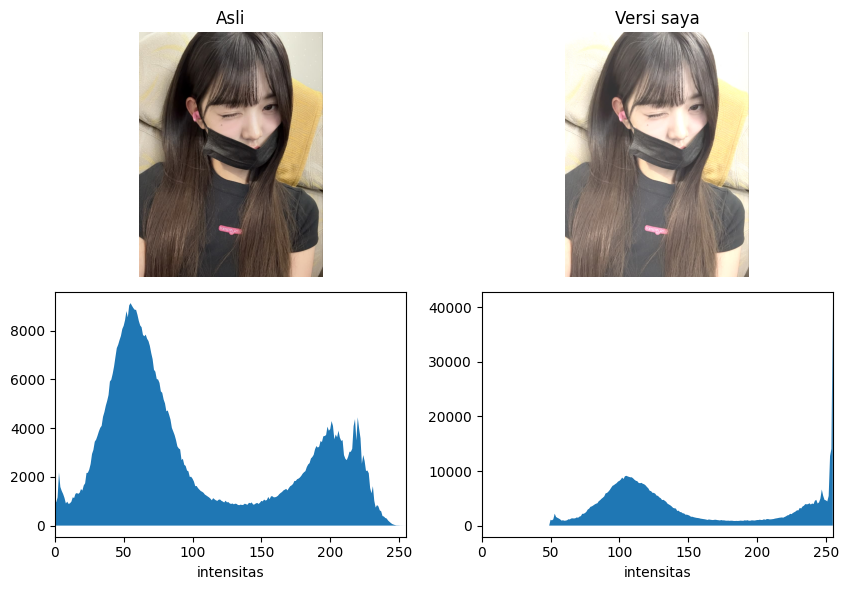

In [46]:
# Tebakan saya: histogram akan condong ke kanan (terang) (isi sebelum menjalankan sel ini)

# TODO: buat variabel `versiku` dari img_rgb dengan operasi kecerahan pilihanmu sendiri
# contoh pola: np.clip(img_rgb.astype(np.int16) * <angka> + <angka>, 0, 255).astype(np.uint8)
versiku = np.clip(img_rgb.astype(np.int16) * 1.0 + 50, 0, 255).astype(np.uint8)

tampilkan_dengan_histogram([img_rgb, versiku], ["Asli", "Versi saya"])

## Bagian 4 · Membaca Statistik: Mean & Standar Deviasi

**Mean** = kecerahan rata-rata seluruh piksel. **Standar deviasi (std)** = lebar sebaran histogram, dipakai sebagai proxy untuk kontras: std kecil = kontras rendah, std besar = kontras tinggi.

In [47]:
mu, sigma = gray.mean(), gray.std()
print(f"Citra asli:  mean = {mu:.1f}   std = {sigma:.1f}")
print()

for nama, citra in [("Asli", img_rgb), ("Gelap", gelap), ("Terang", terang),
                     ("Kontras rendah", rendah), ("Kontras tinggi", tinggi)]:
    g = cv2.cvtColor(citra, cv2.COLOR_RGB2GRAY)
    print(f"{nama:16s}  mean={g.mean():6.1f}   std={g.std():6.1f}")

Citra asli:  mean = 102.9   std = 67.0

Asli              mean= 102.9   std=  67.0
Gelap             mean=  42.7   std=  28.1
Terang            mean= 186.1   std=  49.5
Kontras rendah    mean= 100.8   std=  23.5
Kontras tinggi    mean=  97.5   std= 104.2


### Latihan 2

Dari tabel angka di atas saja (tanpa lihat gambarnya dulu), urutkan kelima citra dari yang **paling gelap** ke **paling terang** hanya berdasarkan nilai mean. Tulis urutanmu, baru jalankan sel untuk mencocokkan dengan gambarnya.

Urutan tebakanmu: ['', '', '', '', '']


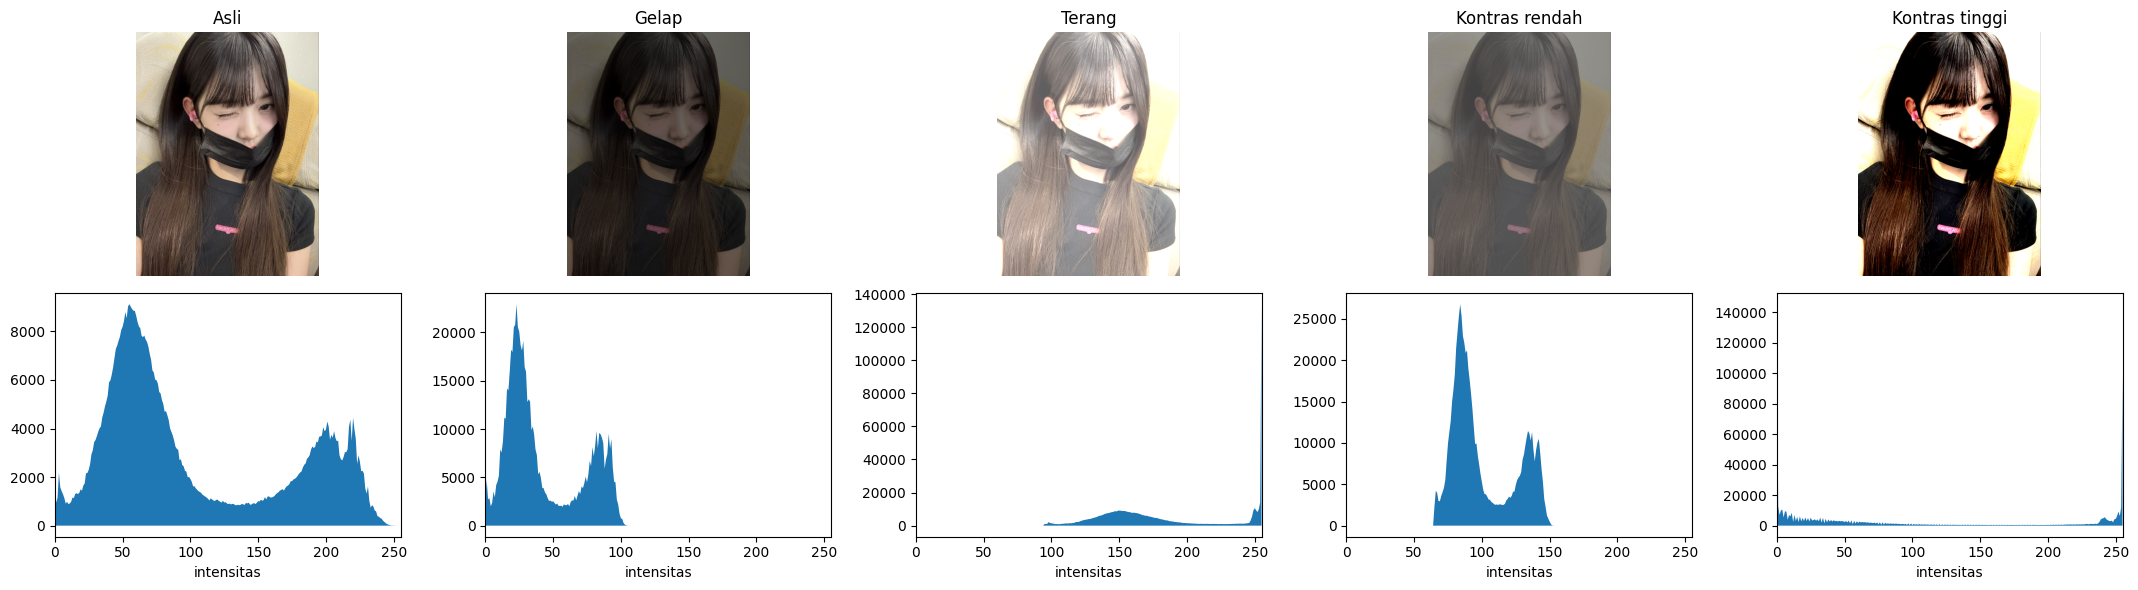

In [48]:
# TODO: isi urutan nama citra dari paling gelap ke paling terang, berdasarkan mean di atas
urutan_tebakan = ["", "", "", "", ""]
print("Urutan tebakanmu:", urutan_tebakan)

tampilkan_dengan_histogram(
    [img_rgb, gelap, terang, rendah, tinggi],
    ["Asli", "Gelap", "Terang", "Kontras rendah", "Kontras tinggi"]
)

## Bagian 5 · Histogram Warna (RGB) vs Grayscale

Citra berwarna bisa dianalisis lewat 1 histogram grayscale (ringkas) atau 3 histogram terpisah per channel R, G, B (lebih detail, menunjukkan warna apa yang dominan).

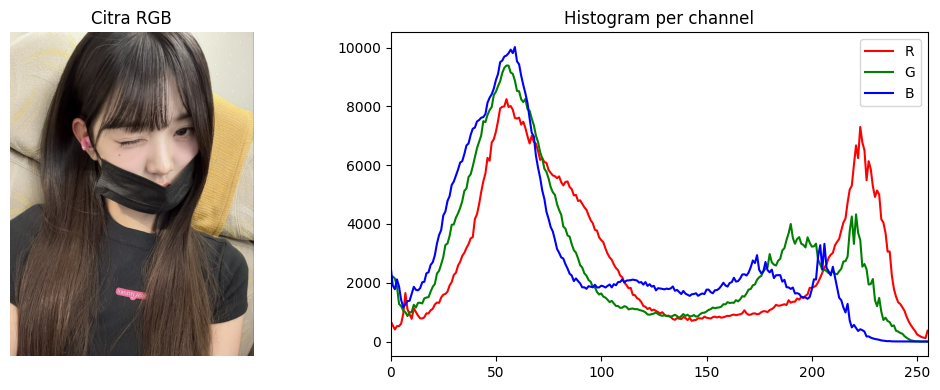

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(img_rgb)
ax[0].set_title("Citra RGB")
ax[0].axis("off")

for ch, warna, nama in zip(cv2.split(img_rgb), ["red", "green", "blue"], ["R", "G", "B"]):
    h = cv2.calcHist([ch], [0], None, [256], [0, 256])
    ax[1].plot(h, color=warna, label=nama)
ax[1].set_xlim(0, 255)
ax[1].legend()
ax[1].set_title("Histogram per channel")
plt.tight_layout()
plt.show()

### Latihan 3

Pakai citra yang ada warna dominan yang jelas (foto sendiri lewat sel upload di Bagian 0, atau `citra.jpg` yang sekarang kalau warnanya sudah cukup jelas). Salin dan modifikasi kode dari Bagian 5 di atas untuk plot histogram per channel-nya. Channel mana yang puncaknya paling tinggi di sisi kanan (dekat 255)? Apakah sesuai dugaanmu dari warna citranya?

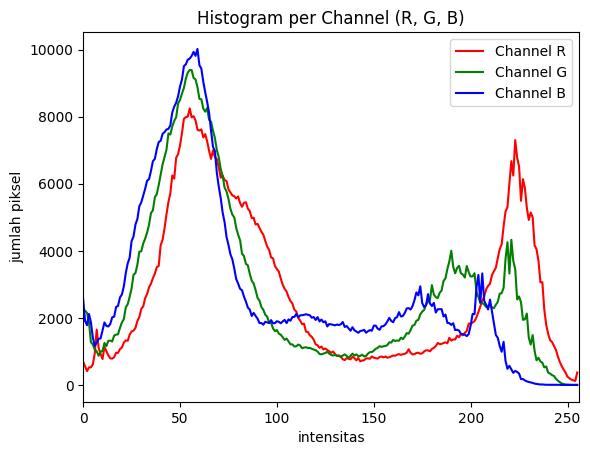

In [59]:
# TODO: hitung dan plot histogram per channel (R, G, B) untuk img_rgb
# boleh salin-modifikasi kode dari Bagian 5

for ch, warna, nama in zip(cv2.split(img_rgb), ["red", "green", "blue"], ["R", "G", "B"]):
    hist = cv2.calcHist([ch], [0], None, [256], [0, 256])
    plt.plot(hist, color=warna, label=f"Channel {nama}")

plt.title("Histogram per Channel (R, G, B)")
plt.xlabel("intensitas")
plt.ylabel("jumlah piksel")
plt.legend()
plt.xlim([0, 256])
plt.show()

**Channel R** (Merah) jaraknya cukup jauh dari G dan B

## Bagian 6 · Tugas: Pemeriksa Kualitas Citra Otomatis

Bangun fungsi `cek_kualitas(path)` yang:

1. Memuat citra dan menghitung mean & std dari histogram grayscale-nya
2. Mengklasifikasikan citra sebagai salah satu dari **underexposed** (mean rendah), **overexposed** (mean tinggi), **kontras rendah** (std kecil), atau **normal**
3. Mencetak hasil klasifikasi beserta nilai mean/std-nya, dan menampilkan citra + histogramnya lewat `tampilkan_dengan_histogram`

Pakai aturan ambang batas (threshold) sendiri yang masuk akal, misalnya mean di bawah 70 = underexposed, mean di atas 190 = overexposed, std di bawah 35 = kontras rendah. Uji fungsimu ke citra asli dan ke variasi gelap/terang/kontras rendah yang sudah dibuat di atas.

wony.jpg          mean= 102.9  std=  67.0  ->  status: normal


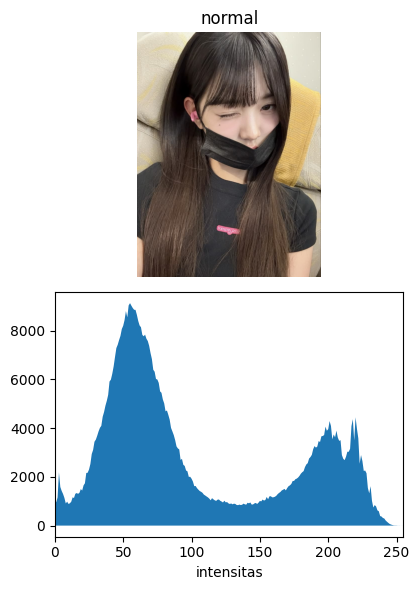

'normal'

In [76]:
def cek_kualitas(path):
    citra = cv2.imread(path)
    citra_rgb = cv2.cvtColor(citra, cv2.COLOR_BGR2RGB)
    g = cv2.cvtColor(citra_rgb, cv2.COLOR_RGB2GRAY)
    mu, sigma = g.mean(), g.std()

    # TODO: tentukan `status` berdasarkan mu dan sigma, pakai aturan di atas

    if mu > 190 or mu > 180:
      status = "overexposed"
    elif mu < 70:
      status = "underexposed"
    elif sigma < 35:
      status = "kontras rendah"
    else:
      status = "normal"

    print(f"{path:16s}  mean={mu:6.1f}  std={sigma:6.1f}  ->  status: {status}")
    tampilkan_dengan_histogram([citra_rgb], [status])
    return status


cek_kualitas("wony.jpg")

Ada perubahan yang ku lakukan yaitu pada kondisi pertama saya menambahkan or untuk status "overexposed" dikarenakan mean `186.1` terlihat overexposure dari pada normal bisa dilihat juga pada histogram normal vs histogram overexposed.

Jika dapat bypass constraint soal dapat disederhanakan kondisi pertama menjadi

```python
if mu > 180: status = "overexposed"
```

gelap.jpg         mean=  42.7  std=  28.2  ->  status: underexposed


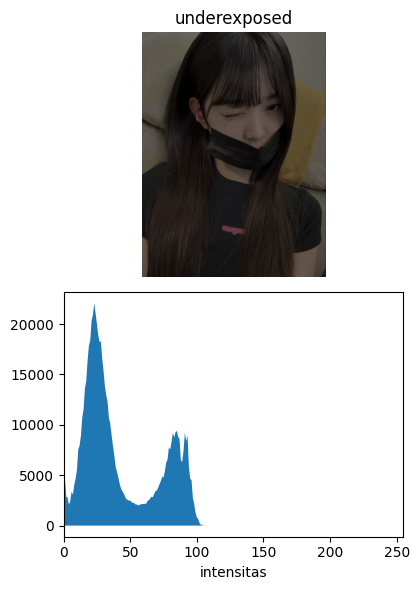

terang.jpg        mean= 186.1  std=  49.4  ->  status: overexposed


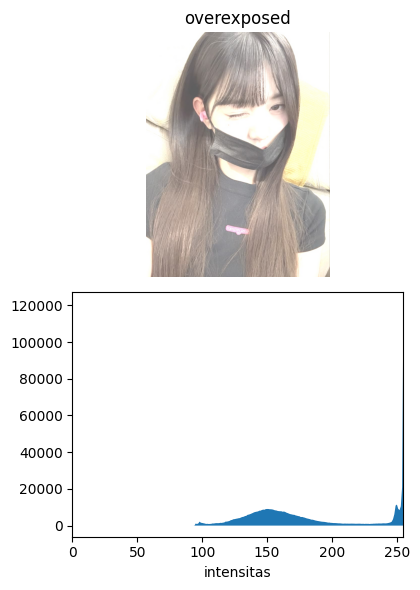

rendah.jpg        mean= 100.8  std=  23.5  ->  status: kontras rendah


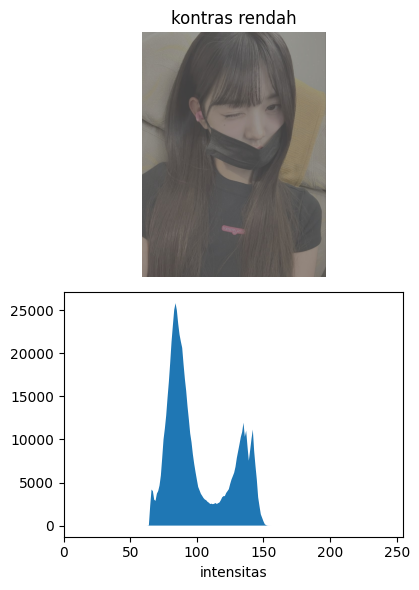

In [77]:
# Uji fungsimu ke variasi yang sudah dibuat tadi
for nama, citra in [("gelap.jpg", gelap), ("terang.jpg", terang), ("rendah.jpg", rendah)]:
    cv2.imwrite(nama, cv2.cvtColor(citra, cv2.COLOR_RGB2BGR))
    cek_kualitas(nama)

## Ringkasan & Sesi Berikutnya

Hari ini kita pakai histogram untuk membaca kecerahan dan kontras citra tanpa perlu melihat gambarnya langsung, dan menghitung statistik dasarnya (mean, standar deviasi). Sesi berikutnya (Sub-CPMK 3): ruang warna dan transformasi citra, konversi RGB ke HSV, dan deteksi objek berbasis warna.